In [3]:
# ============================================================================
# COMPLETE IMPLEMENTATION: ONE-SITE + TWO-SITE DMRG
# ============================================================================

import numpy as np
from scipy.sparse.linalg import LinearOperator, eigsh
import os

os.makedirs("figureAKLT", exist_ok=True)

# ============================================================================
# SPIN OPERATORS
# ============================================================================

def spin_half_operators():
    Sp = np.array([[0, 1], [0, 0]], dtype=complex)
    Sm = np.array([[0, 0], [1, 0]], dtype=complex)
    Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
    Id = np.eye(2, dtype=complex)
    return Sp, Sm, Sz, Id

def spin_one_operators():
    Sz = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]], dtype=complex)
    Sp = np.sqrt(2) * np.array([[0, 1, 0], [0, 0, 1], [0, 0, 0]], dtype=complex)
    Sm = np.sqrt(2) * np.array([[0, 0, 0], [1, 0, 0], [0, 1, 0]], dtype=complex)
    Id = np.eye(3, dtype=complex)
    return Sp, Sm, Sz, Id

# ============================================================================
# MPO CONSTRUCTION
# ============================================================================

def heisenberg_mpo(L, J=1.0, Jz=1.0, h=0.0):
    Sp, Sm, Sz, Id = spin_half_operators()
    d = 2
    chi = 5
    W = []
    
    W_left = np.zeros((1, chi, d, d), dtype=complex)
    W_left[0, 0] = -h * Sz
    W_left[0, 1] = J/2 * Sm
    W_left[0, 2] = J/2 * Sp
    W_left[0, 3] = Jz * Sz
    W_left[0, 4] = Id
    W.append(W_left)
    
    for _ in range(L - 2):
        W_bulk = np.zeros((chi, chi, d, d), dtype=complex)
        W_bulk[0, 0] = Id
        W_bulk[1, 0] = Sp
        W_bulk[2, 0] = Sm
        W_bulk[3, 0] = Sz
        W_bulk[4, 0] = -h * Sz
        W_bulk[4, 1] = J/2 * Sm
        W_bulk[4, 2] = J/2 * Sp
        W_bulk[4, 3] = Jz * Sz
        W_bulk[4, 4] = Id
        W.append(W_bulk)
    
    W_right = np.zeros((chi, 1, d, d), dtype=complex)
    W_right[0, 0] = Id
    W_right[1, 0] = Sp
    W_right[2, 0] = Sm
    W_right[3, 0] = Sz
    W_right[4, 0] = -h * Sz
    W.append(W_right)
    
    return W

def aklt_mpo(L):
    Sp, Sm, Sz, Id = spin_one_operators()
    d = 3
    O = [Sp / np.sqrt(2), Sm / np.sqrt(2), Sz]
    Obar = [Sm / np.sqrt(2), Sp / np.sqrt(2), Sz]
    OO = [O[a] @ O[b] for a in range(3) for b in range(3)]
    ObarObar = [Obar[a] @ Obar[b] for a in range(3) for b in range(3)]
    
    chi = 14
    W = []
    
    W_left = np.zeros((1, chi, d, d), dtype=complex)
    W_left[0, 0] = Id
    for a in range(3):
        W_left[0, 1 + a] = O[a]
    for k in range(9):
        W_left[0, 4 + k] = OO[k] / 3.0
    W.append(W_left)
    
    for _ in range(L - 2):
        W_bulk = np.zeros((chi, chi, d, d), dtype=complex)
        W_bulk[0, 0] = Id
        for a in range(3):
            W_bulk[0, 1 + a] = O[a]
        for k in range(9):
            W_bulk[0, 4 + k] = OO[k] / 3.0
        for a in range(3):
            W_bulk[1 + a, 13] = Obar[a]
        for k in range(9):
            W_bulk[4 + k, 13] = ObarObar[k]
        W_bulk[13, 13] = Id
        W.append(W_bulk)
    
    W_right = np.zeros((chi, 1, d, d), dtype=complex)
    for a in range(3):
        W_right[1 + a, 0] = Obar[a]
    for k in range(9):
        W_right[4 + k, 0] = ObarObar[k]
    W_right[13, 0] = Id
    W.append(W_right)
    
    return W

# ============================================================================
# CANONICALIZATION
# ============================================================================

def left_canonicalize_site(M):
    Dl, d, Dr = M.shape
    Q, R = np.linalg.qr(M.reshape(Dl * d, Dr, order='C'), mode='reduced')
    A = Q.reshape(Dl, d, -1, order='C')
    return A, R

def right_canonicalize_site(M):
    Dl, d, Dr = M.shape
    Q, R = np.linalg.qr(M.reshape(Dl, d * Dr, order='C').T.conj(), mode='reduced')
    B = Q.T.conj().reshape(-1, d, Dr, order='C')
    return B, R.T.conj()

def mixed_canonical(Ms, center):
    L = len(Ms)
    Ms = [M.copy() for M in Ms]
    for i in range(center):
        Ms[i], R = left_canonicalize_site(Ms[i])
        Ms[i + 1] = np.einsum('ij,jkl->ikl', R, Ms[i + 1])
    for i in range(L - 1, center, -1):
        Ms[i], R = right_canonicalize_site(Ms[i])
        Ms[i - 1] = np.einsum('ijk,kl->ijl', Ms[i - 1], R)
    return Ms

# ============================================================================
# ENVIRONMENTS
# ============================================================================

def update_left_env(L_env, A, W):
    return np.einsum('bxy,xsa,bBst,ytc->Bac', L_env, A, W, A.conj())

def update_right_env(R_env, B, W):
    return np.einsum('xsa,bBst,Bac,ytc->bxy', B, W, R_env, B.conj())

def build_right_envs(Ms, Ws):
    L = len(Ms)
    Rs = [None] * (L + 1)
    Rs[L] = np.zeros((1, 1, 1), dtype=complex)
    Rs[L][0, 0, 0] = 1.0
    for i in range(L - 1, 0, -1):
        Rs[i] = update_right_env(Rs[i + 1], Ms[i], Ws[i])
    return Rs

# ============================================================================
# EFFECTIVE HAMILTONIANS (MATRIX-FREE)
# ============================================================================

def heff_one_site_matvec(v, L_env, W, R_env, Dl, d, Dr):
    """Validated one-site matvec from the notes"""
    M = v.reshape((Dl, d, Dr), order='C')
    X = np.einsum('byx,ysz->bxsz', L_env, M)
    Y = np.einsum('bBst,bxsz->Bxtz', W, X)
    HM = np.einsum('Bxtz,Bza->xta', Y, R_env)
    return HM.reshape(Dl * d * Dr, order='C')

def heff_two_site_matvec(v, L_env, W1, W2, R_env, Dl, d1, d2, Dr):
    """Validated two-site matvec from the notes"""
    Theta = v.reshape((Dl, d1, d2, Dr), order='C')
    X = np.einsum('byx,yuvz->bxuvz', L_env, Theta)
    Y = np.einsum('bBus,bxuvz->Bxsvz', W1, X)
    Z = np.einsum('BCvt,Bxsvz->Cxstz', W2, Y)
    HT = np.einsum('Cxstz,Cza->xsta', Z, R_env)
    return HT.reshape(Dl * d1 * d2 * Dr, order='C')

# ============================================================================
# TWO-SITE DMRG (Algorithm 8 from notes)
# ============================================================================

def two_site_dmrg(Ws, Ms, Dmax, num_sweeps=5):
    L = len(Ms)
    energies = []
    
    Ms = mixed_canonical(Ms, 0)
    Rs = build_right_envs(Ms, Ws)
    Ls = [None] * (L + 1)
    Ls[0] = np.zeros((1, 1, 1), dtype=complex)
    Ls[0][0, 0, 0] = 1.0
    
    for sweep in range(num_sweeps):
        # Left-to-right
        for i in range(L - 1):
            Theta = np.einsum('ijk,klm->ijlm', Ms[i], Ms[i + 1])
            Dl, d1, d2, Dr = Theta.shape
            Nloc = Dl * d1 * d2 * Dr
            v0 = Theta.reshape(Nloc, order='C')
            v0 = v0 / np.linalg.norm(v0)
            
            Heff = LinearOperator(
                shape=(Nloc, Nloc),
                matvec=lambda v: heff_two_site_matvec(
                    v, Ls[i], Ws[i], Ws[i + 1], Rs[i + 2], Dl, d1, d2, Dr),
                dtype=complex)
            E, vec = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-6, maxiter=500)
            Theta = vec[:, 0].reshape((Dl, d1, d2, Dr), order='C')
            
            U, S, Vh = np.linalg.svd(
                Theta.reshape(Dl * d1, d2 * Dr, order='C'), full_matrices=False)
            Dnew = min(Dmax, len(S))
            U, S, Vh = U[:, :Dnew], S[:Dnew], Vh[:Dnew, :]
            
            Ms[i] = U.reshape(Dl, d1, Dnew, order='C')
            Ms[i + 1] = (np.diag(S) @ Vh).reshape(Dnew, d2, Dr, order='C')
            
            if i < L - 2:
                Ls[i + 1] = update_left_env(Ls[i], Ms[i], Ws[i])
        
        energies.append(E[0].real)
        
        # Right-to-left
        for i in range(L - 2, -1, -1):
            Theta = np.einsum('ijk,klm->ijlm', Ms[i], Ms[i + 1])
            Dl, d1, d2, Dr = Theta.shape
            Nloc = Dl * d1 * d2 * Dr
            v0 = Theta.reshape(Nloc, order='C')
            v0 = v0 / np.linalg.norm(v0)
            
            Heff = LinearOperator(
                shape=(Nloc, Nloc),
                matvec=lambda v: heff_two_site_matvec(
                    v, Ls[i], Ws[i], Ws[i + 1], Rs[i + 2], Dl, d1, d2, Dr),
                dtype=complex)
            E, vec = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-6, maxiter=500)
            Theta = vec[:, 0].reshape((Dl, d1, d2, Dr), order='C')
            
            U, S, Vh = np.linalg.svd(
                Theta.reshape(Dl * d1, d2 * Dr, order='C'), full_matrices=False)
            Dnew = min(Dmax, len(S))
            U, S, Vh = U[:, :Dnew], S[:Dnew], Vh[:Dnew, :]
            
            Ms[i] = (U @ np.diag(S)).reshape(Dl, d1, Dnew, order='C')
            Ms[i + 1] = Vh.reshape(Dnew, d2, Dr, order='C')
            
            if i > 0:
                Rs[i + 1] = update_right_env(Rs[i + 2], Ms[i + 1], Ws[i + 1])
        
        energies.append(E[0].real)
        if sweep > 0 and abs(energies[-1] - energies[-3]) < 1e-12:
            break
    
    return Ms, energies

# ============================================================================
# ONE-SITE DMRG (Algorithm 7 from notes)
# ============================================================================

def one_site_dmrg(Ws, Ms, Dmax, num_sweeps=5):
    """One-site DMRG following Algorithm 7 of the notes.
    
    Left-to-right: optimize M[i], SVD -> A[i] (left-canonical),
                   absorb SV† into M[i+1], update L[i+1].
    Right-to-left: optimize M[i], SVD -> B[i] (right-canonical),
                   absorb US into M[i-1], update R[i-1].
    """
    L = len(Ms)
    energies = []
    
    # Start in mixed-canonical form with center at site 0
    Ms = mixed_canonical(Ms, 0)
    Rs = build_right_envs(Ms, Ws)
    Ls = [None] * (L + 1)
    Ls[0] = np.zeros((1, 1, 1), dtype=complex)
    Ls[0][0, 0, 0] = 1.0
    
    for sweep in range(num_sweeps):
        # ---- Left-to-right sweep: sites 0 .. L-2 ----
        for i in range(L - 1):
            Dl, d, Dr = Ms[i].shape
            Nloc = Dl * d * Dr
            v0 = Ms[i].reshape(Nloc, order='C')
            v0 = v0 / np.linalg.norm(v0)
            
            Heff = LinearOperator(
                shape=(Nloc, Nloc),
                matvec=lambda v: heff_one_site_matvec(
                    v, Ls[i], Ws[i], Rs[i + 1], Dl, d, Dr),
                dtype=complex)
            E, vec = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-6, maxiter=500)
            M_opt = vec[:, 0].reshape((Dl, d, Dr), order='C')
            
            # SVD split: left-grouped matrix (Dl*d, Dr)
            M_mat = M_opt.reshape(Dl * d, Dr, order='C')
            U, S, Vh = np.linalg.svd(M_mat, full_matrices=False)
            Dnew = min(Dmax, len(S))
            U, S, Vh = U[:, :Dnew], S[:Dnew], Vh[:Dnew, :]
            
            # A[i] is left-canonical
            Ms[i] = U.reshape(Dl, d, Dnew, order='C')
            # Absorb S V† into M[i+1]
            SVh = np.diag(S) @ Vh
            Ms[i + 1] = np.einsum('ij,jkl->ikl', SVh, Ms[i + 1])
            
            # Update left environment
            Ls[i + 1] = update_left_env(Ls[i], Ms[i], Ws[i])
        
        energies.append(E[0].real)
        
        # ---- Right-to-left sweep: sites L-1 .. 1 ----
        for i in range(L - 1, 0, -1):
            Dl, d, Dr = Ms[i].shape
            Nloc = Dl * d * Dr
            v0 = Ms[i].reshape(Nloc, order='C')
            v0 = v0 / np.linalg.norm(v0)
            
            Heff = LinearOperator(
                shape=(Nloc, Nloc),
                matvec=lambda v: heff_one_site_matvec(
                    v, Ls[i], Ws[i], Rs[i + 1], Dl, d, Dr),
                dtype=complex)
            E, vec = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-6, maxiter=500)
            M_opt = vec[:, 0].reshape((Dl, d, Dr), order='C')
            
            # SVD split: right-grouped matrix (Dl, d*Dr)
            M_mat = M_opt.reshape(Dl, d * Dr, order='C')
            U, S, Vh = np.linalg.svd(M_mat, full_matrices=False)
            Dnew = min(Dmax, len(S))
            U, S, Vh = U[:, :Dnew], S[:Dnew], Vh[:Dnew, :]
            
            # B[i] is right-canonical (reshape V†)
            Ms[i] = Vh.reshape(Dnew, d, Dr, order='C')
            # Absorb U S into M[i-1]
            US = U @ np.diag(S)
            Ms[i - 1] = np.einsum('ijk,kl->ijl', Ms[i - 1], US)
            
            # Update right environment
            Rs[i] = update_right_env(Rs[i + 1], Ms[i], Ws[i])
        
        energies.append(E[0].real)
        if sweep > 0 and abs(energies[-1] - energies[-3]) < 1e-12:
            break
    
    return Ms, energies

# ============================================================================
# INITIAL MPS
# ============================================================================

def random_mps(L, d, D):
    Ms = []
    Ms.append(np.random.randn(1, d, min(D, d)) + 1j * np.random.randn(1, d, min(D, d)))
    for i in range(1, L - 1):
        Dl = Ms[-1].shape[2]
        Dr = min(D, d ** min(i + 1, L - i - 1))
        Ms.append(np.random.randn(Dl, d, Dr) + 1j * np.random.randn(Dl, d, Dr))
    Dl = Ms[-1].shape[2]
    Ms.append(np.random.randn(Dl, d, 1) + 1j * np.random.randn(Dl, d, 1))
    return Ms

def aklt_exact_mps(L):
    Ap = np.array([[0, np.sqrt(2/3)], [0, 0]], dtype=complex)
    A0 = np.array([[-1/np.sqrt(3), 0], [0, 1/np.sqrt(3)]], dtype=complex)
    Am = np.array([[0, 0], [-np.sqrt(2/3), 0]], dtype=complex)
    Ms = []
    for i in range(L):
        if i == 0:
            M = np.zeros((1, 3, 2), dtype=complex)
            M[0, 0, :] = Ap[0, :]
            M[0, 1, :] = A0[0, :]
            M[0, 2, :] = Am[0, :]
        elif i == L - 1:
            M = np.zeros((2, 3, 1), dtype=complex)
            M[:, 0, 0] = Ap[:, 0]
            M[:, 1, 0] = A0[:, 0]
            M[:, 2, 0] = Am[:, 0]
        else:
            M = np.zeros((2, 3, 2), dtype=complex)
            M[:, 0, :] = Ap
            M[:, 1, :] = A0
            M[:, 2, :] = Am
        Ms.append(M)
    return Ms

# ============================================================================
# RUN BOTH ALGORITHMS
# ============================================================================

np.random.seed(42)

print("=" * 70)
print("COMPARISON: ONE-SITE vs TWO-SITE DMRG")
print("=" * 70)

print("\n--- S=1/2 Heisenberg ---")
print(f"{'L':>4} {'E (2-site)':>18} {'E (1-site)':>18} {'diff':>12}")
print("-" * 56)

heisenberg_1s = {}
heisenberg_2s = {}

for L in [6, 8, 10, 12]:
    Ws = heisenberg_mpo(L)
    
    np.random.seed(42)
    Ms = random_mps(L, 2, 20)
    Ms_2s, en_2s = two_site_dmrg(Ws, Ms, Dmax=30, num_sweeps=6)
    heisenberg_2s[L] = en_2s
    
    # For one-site: start from the two-site result for fair comparison
    # (notes warn one-site is prone to local minima from random start)
    Ms_1s, en_1s = one_site_dmrg(Ws, Ms_2s, Dmax=30, num_sweeps=6)
    heisenberg_1s[L] = en_1s
    
    diff = abs(en_2s[-1] - en_1s[-1])
    print(f"{L:>4} {en_2s[-1]:>18.10f} {en_1s[-1]:>18.10f} {diff:>12.2e}")

print("\n--- AKLT ---")
print(f"{'L':>4} {'E (2-site)':>18} {'E (1-site)':>18} {'E_exact':>18} {'err(2s)':>10} {'err(1s)':>10}")
print("-" * 82)

aklt_1s = {}
aklt_2s = {}

for L in [6, 8, 10, 12]:
    Ws = aklt_mpo(L)
    E_exact = -2/3 * (L - 1)
    
    np.random.seed(42)
    Ms = random_mps(L, 3, 10)
    Ms_2s, en_2s = two_site_dmrg(Ws, Ms, Dmax=15, num_sweeps=6)
    aklt_2s[L] = en_2s
    
    Ms_1s, en_1s = one_site_dmrg(Ws, Ms_2s, Dmax=15, num_sweeps=6)
    aklt_1s[L] = en_1s
    
    err_2s = abs(en_2s[-1] - E_exact)
    err_1s = abs(en_1s[-1] - E_exact)
    print(f"{L:>4} {en_2s[-1]:>18.10f} {en_1s[-1]:>18.10f} {E_exact:>18.10f} {err_2s:>10.2e} {err_1s:>10.2e}")

# Verify exact AKLT MPS
print("\n--- AKLT Exact MPS Verification ---")
for L in [6, 8, 10, 12]:
    Ws = aklt_mpo(L)
    Ms = aklt_exact_mps(L)
    
    norm_env = np.ones((1, 1), dtype=complex)
    for i in range(L):
        norm_env = np.einsum('xy,xsa,ysc->ac', norm_env, Ms[i], Ms[i].conj())
    norm = norm_env[0, 0].real
    
    L_env = np.zeros((1, 1, 1), dtype=complex)
    L_env[0, 0, 0] = 1.0
    for i in range(L):
        L_env = np.einsum('bxy,xsa,bBst,ytc->Bac', L_env, Ms[i], Ws[i], Ms[i].conj())
    E_mps = L_env[0, 0, 0].real / norm
    E_exact = -2/3 * (L - 1)
    print(f"  L={L}: E_mps={E_mps:.10f}, exact={E_exact:.10f}, err={abs(E_mps-E_exact):.2e}")

print("\n" + "=" * 70)
print("COMPUTATION COMPLETE")
print("=" * 70)

COMPARISON: ONE-SITE vs TWO-SITE DMRG

--- S=1/2 Heisenberg ---
   L         E (2-site)         E (1-site)         diff
--------------------------------------------------------
   6      -2.4935771339      -2.4935771339     2.22e-15
   8      -3.3749325987      -3.3749325987     9.33e-15
  10      -4.2580352073      -4.2580352073     4.80e-14
  12      -5.1420906328      -5.1420906328     2.84e-14

--- AKLT ---
   L         E (2-site)         E (1-site)            E_exact    err(2s)    err(1s)
----------------------------------------------------------------------------------
   6      -3.3333333333      -3.3333333333      -3.3333333333   1.33e-15   2.22e-15
   8      -4.6666666667      -4.6666666667      -4.6666666667   8.88e-16   5.33e-15
  10      -6.0000000000      -6.0000000000      -6.0000000000   0.00e+00   1.78e-15
  12      -7.3333333333      -7.3333333333      -7.3333333333   3.55e-15   8.88e-16

--- AKLT Exact MPS Verification ---
  L=6: E_mps=-3.3333333333, exact=-3.33333333

Generating Heisenberg figures...


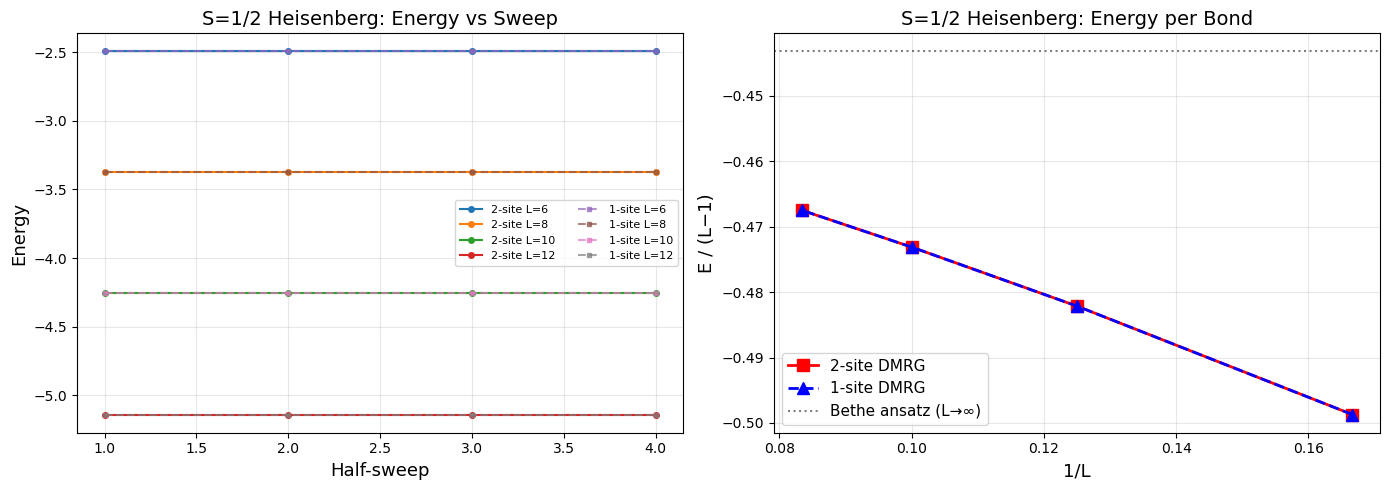

Saved: figureAKLT/heisenberg_energy.png


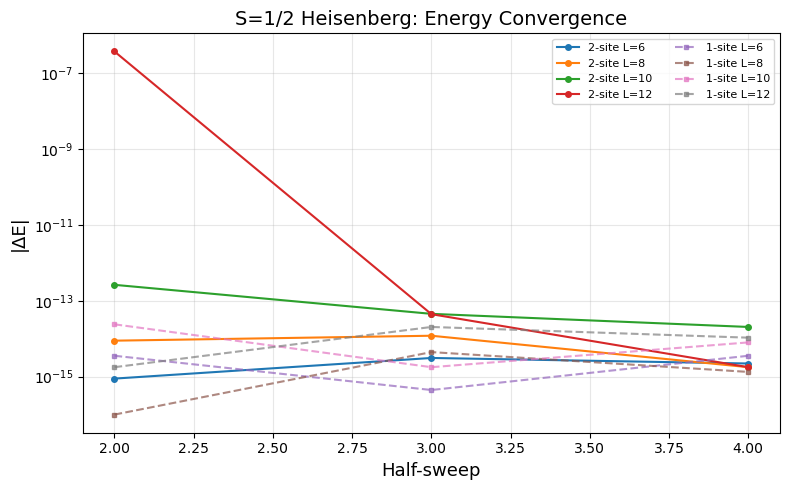

Saved: figureAKLT/heisenberg_convergence.png


In [4]:
# ============================================================================
# CELL: HEISENBERG FIGURES
# ============================================================================
import matplotlib.pyplot as plt

print("Generating Heisenberg figures...")

# Figure 1: Energy convergence per sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for L in sorted(heisenberg_2s.keys()):
    en = heisenberg_2s[L]
    ax.plot(range(1, len(en) + 1), en, 'o-', label=f'2-site L={L}', markersize=4)
for L in sorted(heisenberg_1s.keys()):
    en = heisenberg_1s[L]
    ax.plot(range(1, len(en) + 1), en, 's--', label=f'1-site L={L}', markersize=3, alpha=0.7)
ax.set_xlabel('Half-sweep', fontsize=13)
ax.set_ylabel('Energy', fontsize=13)
ax.set_title('S=1/2 Heisenberg: Energy vs Sweep', fontsize=14)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Figure 2: Energy per bond vs 1/L
ax = axes[1]
Ls = sorted(heisenberg_2s.keys())
E_per_bond_2s = [heisenberg_2s[L][-1] / (L - 1) for L in Ls]
E_per_bond_1s = [heisenberg_1s[L][-1] / (L - 1) for L in Ls]
inv_L = [1.0 / L for L in Ls]
ax.plot(inv_L, E_per_bond_2s, 'rs-', markersize=8, linewidth=2, label='2-site DMRG')
ax.plot(inv_L, E_per_bond_1s, 'b^--', markersize=8, linewidth=2, label='1-site DMRG')
ax.axhline(y=-0.4432, color='k', linestyle=':', alpha=0.5, label='Bethe ansatz (L→∞)')
ax.set_xlabel('1/L', fontsize=13)
ax.set_ylabel('E / (L−1)', fontsize=13)
ax.set_title('S=1/2 Heisenberg: Energy per Bond', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figureAKLT/heisenberg_energy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figureAKLT/heisenberg_energy.png")

# Figure 3: Convergence |dE|
fig, ax = plt.subplots(figsize=(8, 5))
for L in sorted(heisenberg_2s.keys()):
    en = heisenberg_2s[L]
    dE = [abs(en[i] - en[i - 1]) for i in range(1, len(en))]
    dE = [max(x, 1e-16) for x in dE]
    ax.semilogy(range(2, len(en) + 1), dE, 'o-', label=f'2-site L={L}', markersize=4)
for L in sorted(heisenberg_1s.keys()):
    en = heisenberg_1s[L]
    dE = [abs(en[i] - en[i - 1]) for i in range(1, len(en))]
    dE = [max(x, 1e-16) for x in dE]
    ax.semilogy(range(2, len(en) + 1), dE, 's--', label=f'1-site L={L}', markersize=3, alpha=0.7)
ax.set_xlabel('Half-sweep', fontsize=13)
ax.set_ylabel('|ΔE|', fontsize=13)
ax.set_title('S=1/2 Heisenberg: Energy Convergence', fontsize=14)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figureAKLT/heisenberg_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figureAKLT/heisenberg_convergence.png")

Generating AKLT figures...


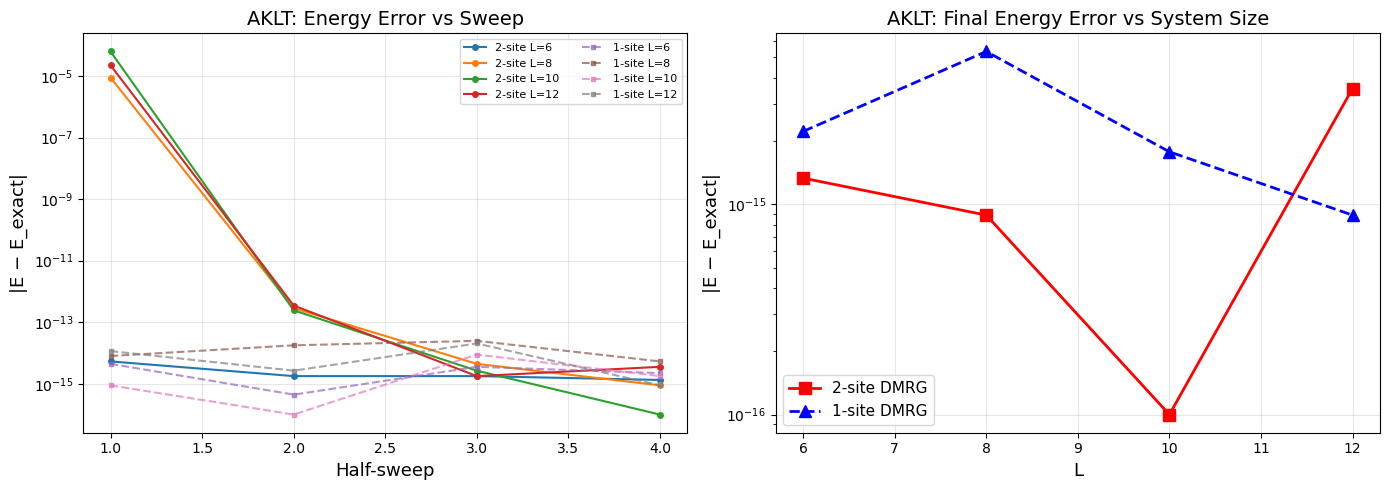

Saved: figureAKLT/aklt_energy.png


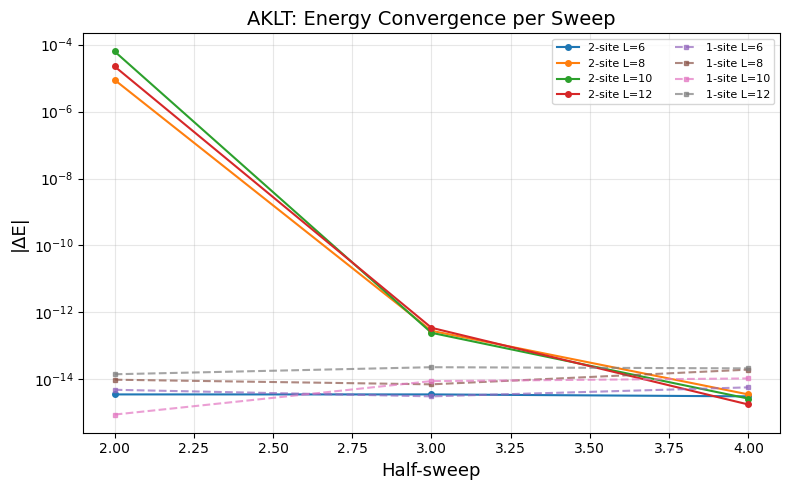

Saved: figureAKLT/aklt_convergence.png

SUMMARY TABLE: ONE-SITE vs TWO-SITE DMRG
Model           L          E(2-site)          E(1-site)            E_exact     |diff|
------------------------------------------------------------------------------------
Heisenberg      6      -2.4935771339      -2.4935771339                ---   2.22e-15
Heisenberg      8      -3.3749325987      -3.3749325987                ---   9.33e-15
Heisenberg     10      -4.2580352073      -4.2580352073                ---   4.80e-14
Heisenberg     12      -5.1420906328      -5.1420906328                ---   2.84e-14
AKLT            6      -3.3333333333      -3.3333333333      -3.3333333333   8.88e-16
AKLT            8      -4.6666666667      -4.6666666667      -4.6666666667   6.22e-15
AKLT           10      -6.0000000000      -6.0000000000      -6.0000000000   1.78e-15
AKLT           12      -7.3333333333      -7.3333333333      -7.3333333333   4.44e-15

All figures saved to figureAKLT/


In [5]:
# ============================================================================
# CELL: AKLT FIGURES
# ============================================================================

print("Generating AKLT figures...")

# Figure 4: AKLT energy error vs sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for L in sorted(aklt_2s.keys()):
    en = aklt_2s[L]
    E_exact = -2/3 * (L - 1)
    err = [abs(e - E_exact) for e in en]
    err = [max(x, 1e-16) for x in err]
    ax.semilogy(range(1, len(en) + 1), err, 'o-', label=f'2-site L={L}', markersize=4)
for L in sorted(aklt_1s.keys()):
    en = aklt_1s[L]
    E_exact = -2/3 * (L - 1)
    err = [abs(e - E_exact) for e in en]
    err = [max(x, 1e-16) for x in err]
    ax.semilogy(range(1, len(en) + 1), err, 's--', label=f'1-site L={L}', markersize=3, alpha=0.7)
ax.set_xlabel('Half-sweep', fontsize=13)
ax.set_ylabel('|E − E_exact|', fontsize=13)
ax.set_title('AKLT: Energy Error vs Sweep', fontsize=14)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# Figure 5: Final error vs L
ax = axes[1]
Ls = sorted(aklt_2s.keys())
err_2s = [max(abs(aklt_2s[L][-1] - (-2/3*(L-1))), 1e-16) for L in Ls]
err_1s = [max(abs(aklt_1s[L][-1] - (-2/3*(L-1))), 1e-16) for L in Ls]
ax.semilogy(Ls, err_2s, 'rs-', markersize=8, linewidth=2, label='2-site DMRG')
ax.semilogy(Ls, err_1s, 'b^--', markersize=8, linewidth=2, label='1-site DMRG')
ax.set_xlabel('L', fontsize=13)
ax.set_ylabel('|E − E_exact|', fontsize=13)
ax.set_title('AKLT: Final Energy Error vs System Size', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("figureAKLT/aklt_energy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figureAKLT/aklt_energy.png")

# Figure 6: AKLT convergence |dE|
fig, ax = plt.subplots(figsize=(8, 5))
for L in sorted(aklt_2s.keys()):
    en = aklt_2s[L]
    dE = [abs(en[i] - en[i - 1]) for i in range(1, len(en))]
    dE = [max(x, 1e-16) for x in dE]
    ax.semilogy(range(2, len(en) + 1), dE, 'o-', label=f'2-site L={L}', markersize=4)
for L in sorted(aklt_1s.keys()):
    en = aklt_1s[L]
    dE = [abs(en[i] - en[i - 1]) for i in range(1, len(en))]
    dE = [max(x, 1e-16) for x in dE]
    ax.semilogy(range(2, len(en) + 1), dE, 's--', label=f'1-site L={L}', markersize=3, alpha=0.7)
ax.set_xlabel('Half-sweep', fontsize=13)
ax.set_ylabel('|ΔE|', fontsize=13)
ax.set_title('AKLT: Energy Convergence per Sweep', fontsize=14)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figureAKLT/aklt_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figureAKLT/aklt_convergence.png")

# Summary
print("\n" + "=" * 70)
print("SUMMARY TABLE: ONE-SITE vs TWO-SITE DMRG")
print("=" * 70)
print(f"{'Model':<12} {'L':>4} {'E(2-site)':>18} {'E(1-site)':>18} {'E_exact':>18} {'|diff|':>10}")
print("-" * 84)
for L in sorted(heisenberg_2s.keys()):
    e2 = heisenberg_2s[L][-1]
    e1 = heisenberg_1s[L][-1]
    print(f"{'Heisenberg':<12} {L:>4} {e2:>18.10f} {e1:>18.10f} {'---':>18} {abs(e2-e1):>10.2e}")
for L in sorted(aklt_2s.keys()):
    e2 = aklt_2s[L][-1]
    e1 = aklt_1s[L][-1]
    ex = -2/3 * (L - 1)
    print(f"{'AKLT':<12} {L:>4} {e2:>18.10f} {e1:>18.10f} {ex:>18.10f} {abs(e2-e1):>10.2e}")

print("\nAll figures saved to figureAKLT/")